# Common Task 1.2 Dataset preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Reading Data

In [2]:
def read_txt(path):
    rows = []
    with open(path, "r", encoding="utf-8") as fh:
        lines = fh.read().splitlines()
    for line in lines:
        parts = line.split(": ")
        if len(parts) < 4:
            continue
        rows.append({
            "Event Type": parts[0].strip(),
            "Interaction": parts[1].strip(),
            "Feynman Diagram": parts[2].strip(),
            "Amplitude": parts[-2].strip(),
            "Squared Amplitude": parts[-1].strip()
        })
    return rows

In [3]:
base_dir = "/kaggle/input/datasets/arnavtripathi01/symba-test-data/SYMBA - Test Data"

qed_data = []
qcd_data = []

for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)
    rows = read_txt(path)
    if "QED" in file:
        qed_data.extend(rows)
    if "QCD" in file:
        qcd_data.extend(rows)

In [4]:
qed_df = pd.DataFrame(qed_data)
qcd_df = pd.DataFrame(qcd_data)

print("QED dataset size:", len(qed_df))
print("QCD dataset size:", len(qcd_df))

QED dataset size: 360
QCD dataset size: 234


In [5]:
qed_df.head(3)

,Event Type,Interaction,Feynman Diagram,Amplitude,Squared Amplitude
0,Interaction,e_eps_60(X)^(*) AntiPart e_eta_138(X) to mu...,"Vertex V_1:mu(X_3), AntiPart mu(X_4), OffShel...","-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_1...",1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s...
1,Interaction,e_gam_265(X)^(*) AntiPart e_del_260(X) to t...,"Vertex V_1:t(X_3), AntiPart t(X_4), OffShell ...","-1/2*i*e^2*gamma_{+%\tau_428,%gam_262,%eps_110...",1/4*e^4*(16*m_e^2*m_t^2 + 8*m_t^2*s_12 + 8*s_1...
2,Interaction,e_gam_344(X)^(*) AntiPart e_del_320(X) to u...,"Vertex V_1:u(X_3), AntiPart u(X_4), OffShell ...","1/3*i*e^2*gamma_{+%\sigma_622,%eta_238,%beta_1...",1/9*e^4*(16*m_e^2*m_u^2 + 8*m_u^2*s_12 + 8*s_1...


In [6]:
qcd_df.head(3)

,Event Type,Interaction,Feynman Diagram,Amplitude,Squared Amplitude
0,Interaction,"t_{A_61,eps_25}(X)^(*) AntiPart t_{B_72,eta_1...","Vertex V_0:u(X_3), AntiPart u(X_4), OffShell ...","-1/4*i*g^2*gamma_{+%\sigma_129,%eta_96,%gam_97...",-1/144*g^4*((-16)*m_t^2*m_u^2 + (-8)*m_u^2*s_1...
1,Interaction,"t_{A_87,alpha_131}(X)^(*) AntiPart t_{B_105,b...","Vertex V_1:d(X_3), AntiPart d(X_4), OffShell ...","1/12*i*g^2*gamma_{%\mu_356,%eta_321,%gam_296}*...",-1/16*g^4*((-16)*m_d^2*m_t^2 + (-8)*m_d^2*s_12...
2,Interaction,"t_{A_107,gam_424}(X)^(*) AntiPart t_{B_132,de...","Vertex V_0:s(X_3), AntiPart s(X_4), OffShell ...","-1/4*i*g^2*gamma_{+%\tau_412,%eta_597,%eps_94}...",-1/144*g^4*((-16)*m_s^2*m_t^2 + (-8)*m_s^2*s_1...


In [7]:
print("QED Amplitude:")
print(qed_df['Amplitude'].iloc[0])
print("----")
print("QED Squared Amplitude:")
print(qed_df['Squared Amplitude'].iloc[0])

QED Amplitude:
-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43,%gam_166}(p_2)_v^(*)*mu_{i_45,%gam_165}(p_3)_u^(*)*mu_{j_45,%del_165}(p_4)_v/(m_e^2 + s_12 + 1/2*reg_prop)
----
QED Squared Amplitude:
1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_e^2*s_34)*(m_e^2 + s_12 + 1/2*reg_prop)^(-2)


In [8]:
print("QCD Amplitude:")
print(qcd_df['Amplitude'].iloc[0])
print("----")
print("QCD Squared Amplitude")
print(qcd_df['Squared Amplitude'].iloc[0])

QCD Amplitude:
-1/4*i*g^2*gamma_{+%\sigma_129,%eta_96,%gam_97}*gamma_{%\sigma_129,%gam_98,%eta_97}*(t_{k_3,%D_48,%eta_96}(p_2)_v^(*)*t_{i_3,%C_56,%gam_97}(p_1)_u*u_{l_3,%C_56,%gam_98}(p_3)_u^(*)*u_{j_5,%D_48,%eta_97}(p_4)_v + -1/3*t_{k_3,%C_57,%eta_96}(p_2)_v^(*)*t_{i_3,%C_57,%gam_97}(p_1)_u*u_{l_3,%D_49,%gam_98}(p_3)_u^(*)*u_{j_5,%D_49,%eta_97}(p_4)_v)/(m_t^2 + s_12 + 1/2*reg_prop)
----
QCD Squared Amplitude
-1/144*g^4*((-16)*m_t^2*m_u^2 + (-8)*m_u^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_t^2*s_34)*(m_t^2 + s_12 + 1/2*reg_prop)^(-2) + 1/16*i*g^2*(i*g^2*((-16)*m_t^2*m_u^2 + (-8)*m_u^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_t^2*s_34)/(m_t^2 + s_12 + 1/2*reg_prop) + 32/9*i*g^2*(m_t^2*m_u^2 + 1/2*m_u^2*s_12 + 1/2*s_14*s_23 + 1/2*s_13*s_24 + 1/2*m_t^2*s_34)/(m_t^2 + s_12 + 1/2*reg_prop))/(m_t^2 + s_12 + 1/2*reg_prop)


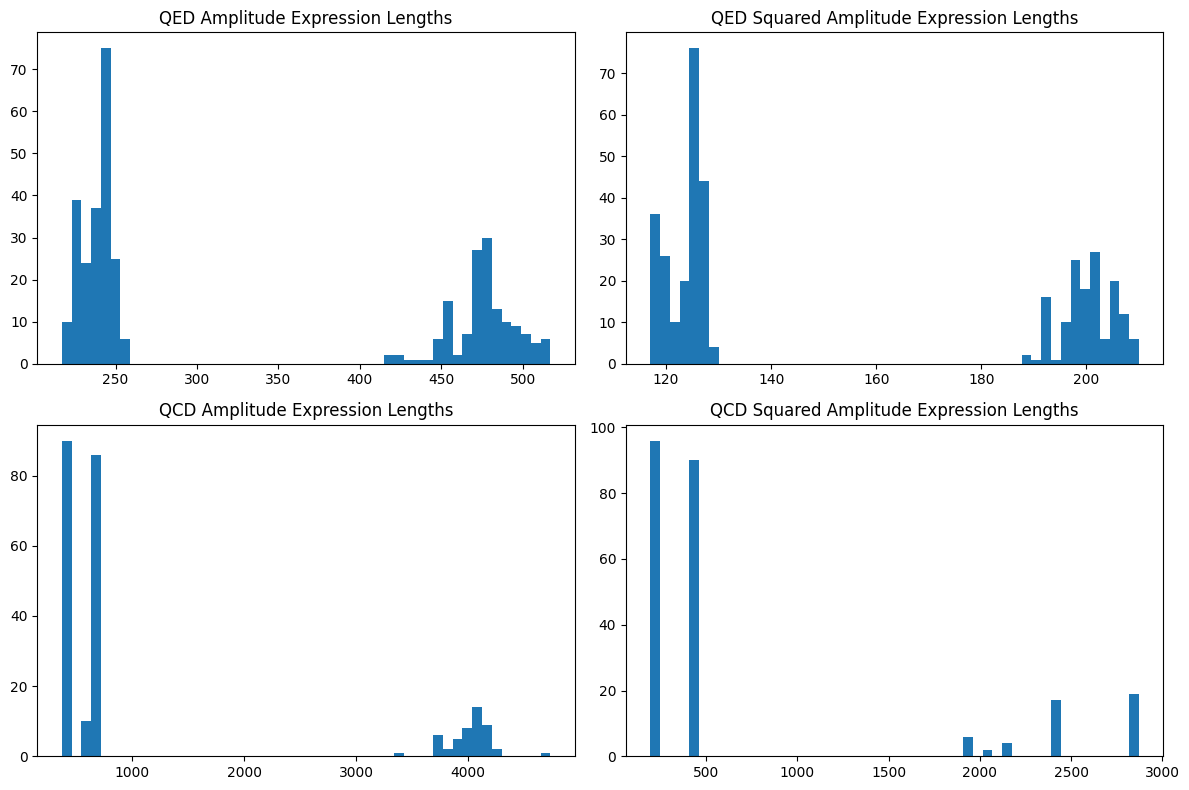

In [9]:
# Plotting sequence lengths of QED/QCD Amplitude and Squared Amplitude expressions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(qed_df['Amplitude'].str.len(), bins=50)
axes[0,0].set_title("QED Amplitude Expression Lengths")

axes[0,1].hist(qed_df['Squared Amplitude'].str.len(), bins=50)
axes[0,1].set_title("QED Squared Amplitude Expression Lengths")

axes[1,0].hist(qcd_df['Amplitude'].str.len(), bins=50)
axes[1,0].set_title("QCD Amplitude Expression Lengths")

axes[1,1].hist(qcd_df['Squared Amplitude'].str.len(), bins=50)
axes[1,1].set_title("QCD Squared Amplitude Expression Lengths")

plt.tight_layout()
plt.show()

## Train-Val-Test Split

In [10]:
from sklearn.model_selection import train_test_split

# split QED
qed_train, temp_df = train_test_split(qed_df, test_size=0.2, random_state=42, shuffle=True)
qed_val, qed_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# split QCD
qcd_train, temp_df = train_test_split(qcd_df, test_size=0.2, random_state=42, shuffle=True)
qcd_val, qcd_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print(f"QED -> Train size : {len(qed_train)}, Validation size : {len(qed_val)}, Test size : {len(qed_test)}")
print(f"QCD -> Train size : {len(qcd_train)}, Validation size : {len(qcd_val)}, Test size : {len(qcd_test)}")

qed_train.to_csv("qed_train.csv")
qed_val.to_csv("qed_val.csv")
qed_test.to_csv("qed_test.csv")

qcd_train.to_csv("qcd_train.csv")
qcd_val.to_csv("qcd_val.csv")
qcd_test.to_csv("qcd_test.csv")

QED -> Train size : 288, Validation size : 36, Test size : 36
QCD -> Train size : 187, Validation size : 23, Test size : 24


## Estimating Index Pool Size

In [11]:
import re

def estimate_pool_sizes(df, amp_col="Amplitude", sq_col="Squared Amplitude"):
    "Estimate optimal pool sizes for combined Amplitude and Squared Amplitude expressions"
    idx_pat = re.compile(r'(?!p_)(?!s_)(?!m_)(?![ijkl]_)[A-Za-z%\\]+_\d+')
    pidx_pat = re.compile(r'\b([ijkl])_(\d+)\b')
    mom_pat = re.compile(r'\bp_(\d+)\b')

    max_idx = 0
    max_pidx = 0
    max_mom = 0

    for _, row in df.iterrows():
        text = f"{row.get(amp_col, '')} || {row.get(sq_col, '')}"
        idx_set = set(m.group(0) for m in idx_pat.finditer(text))
        pidx_set = set(m.group(0) for m in pidx_pat.finditer(text))
        mom_set = set(m.group(0) for m in mom_pat.finditer(text))
        max_idx = max(max_idx, len(idx_set))
        max_pidx = max(max_pidx, len(pidx_set))
        max_mom = max(max_mom, len(mom_set))

    return {
        "max_index_per_sample": max_idx,
        "max_particle_per_sample": max_pidx,
        "max_momentum_per_sample": max_mom,
    }

In [12]:
# Will use a pool size slightly higher than the max index found for a sample.
qed_stats = estimate_pool_sizes(qed_train)
qcd_stats = estimate_pool_sizes(qcd_train)

print("QED:")
print(f"Index Candidates           : {qed_stats['max_index_per_sample']}")
print(f"Particle Index Candidates  : {qed_stats['max_particle_per_sample']}")
print(f"Momentum Candidates        : {qed_stats['max_momentum_per_sample']}")
print("\n")

print("QCD:")
print(f"Index Candidates           : {qcd_stats['max_index_per_sample']}")
print(f"Particle Index Candidates  : {qcd_stats['max_particle_per_sample']}")
print(f"Momentum Candidates        : {qcd_stats['max_momentum_per_sample']}")

QED:
Index Candidates           : 9
Particle Index Candidates  : 4
Momentum Candidates        : 4


QCD:
Index Candidates           : 108
Particle Index Candidates  : 4
Momentum Candidates        : 4


## Frequent Fractions occuring in the Data

In [13]:
from collections import Counter, OrderedDict

def get_fraction_counts(df_list):
    """Extract frequency of different fractions."""
    frac_pattern = re.compile(r'\b\d+/\d+\b')
    counter = Counter()
    
    for df in df_list:
        combined_text = df.get('Amplitude', '').astype(str) + " || " + df.get('Squared Amplitude', '').astype(str)
        all_text = " ".join(combined_text.values)
        counter.update(frac_pattern.findall(all_text))
        
    return counter

In [14]:
all_fractions_counter = get_fraction_counts([qed_train, qcd_train])

print("Top 10 fractions overall:")
for frac, count in all_fractions_counter.most_common(10):
    print(f"{frac} : {count}")

Top 10 fractions overall:
1/2 : 4302
1/16 : 159
1/9 : 121
4/9 : 106
1/448 : 100
16/7 : 88
1/144 : 82
1/3 : 79
1/6 : 72
8/7 : 61


## Tokenizer

In [15]:
import json
import unicodedata
import warnings
from typing import List, Tuple, Dict, Any
from tqdm.auto import tqdm

class PittTokenizer:
    """Physics-informed tokenizer for amplitudes and squared amplitudes expressions."""
    def __init__(
        self,
        index_token_pool_size = 120,
        momentum_token_pool_size = 10,
        particle_index_pool_size = 10,
        special_symbols = None,
        unk_idx = 3
    ):
        self.index_pool_size = int(index_token_pool_size)
        self.momentum_pool_size = int(momentum_token_pool_size)
        self.particle_index_pool_size = int(particle_index_pool_size)
        self.index_tokens = [f"INDEX_{i}" for i in range(self.index_pool_size)]
        self.momentum_tokens = [f"MOMENTUM_{i}" for i in range(self.momentum_pool_size)]
        self.pindex_tokens = [f"PINDEX_{i}" for i in range(self.particle_index_pool_size)]
        self.special_symbols = special_symbols or ["<BOS>", "<PAD>", "<EOS>", "<UNK>", "<SEP>"]
        self.unk_idx = unk_idx

        # regex patterns
        self._re_whitespace = re.compile(r"\s+")
        self._re_unicode_norm = unicodedata.normalize
        self._re_gamma_token = re.compile(r'gamma_\{([^}]+)\}')
        self._re_wavefunction = re.compile(r'\b([A-Za-z]+)_\{([^}]+)\}\(([^)]+)\)(_[A-Za-z]+)(\^CONJ)?')
        self._re_momentum = re.compile(r'\bp_(\d+)\b')
        self._re_mandelstam = re.compile(r'\bs_(\d+)\b')
        self._re_mass = re.compile(r'\bm_[A-Za-z]+\b')
        self._re_particle_index = re.compile(r'\b([ijkl])_(\d+)\b')
        # candidate indices excluding mass/momentum/mandelstam/particle indices
        self._re_index_candidate = re.compile(r'(?!p_)(?!s_)(?!m_)(?![ijkl]_)[A-Za-z%\\]+_\d+')
        # operators and separators
        self._operators = list('/+-*^,{}()[]:=') 

    # ---- Normalization Utilities ----
    def normalize_unicode_and_whitespace(self, expression):
        """Apply unicode normalization and collapse whitespace."""
        if expression is None:
            return ""
        expr = self._re_unicode_norm("NFKC", expression)
        expr = self._re_whitespace.sub(" ", expr).strip()
        return expr

    def fix_brace_spaces(self, expr):
        """Canonicalize spacing inside {...} blocks:"""
        def clean(match):
            inner = match.group(1)
            inner = inner.strip()
            inner = re.sub(r'\s*,\s*', ',', inner)
            inner = re.sub(r'\s*\+\s*', '+', inner)
            inner = re.sub(r'\s*-\s*', '-', inner)
            return '{' + inner + '}'
        return re.sub(r'\{([^}]*)\}', clean, expr)

    def preprocess_expression(self, expression):
        """Canonicalize common physics tokens and simple formatting."""
        expr = self.normalize_unicode_and_whitespace(str(expression))
        expr = expr.replace("me", "m_e")
        expr = expr.replace("reg_prop", "REG_PROP")
        expr = expr.replace("(*)", "CONJ")
        expr = expr.replace("+-", "-").replace("-+", "-")
        expr = re.sub(r'\s*\*\s*', '*', expr)
        expr = re.sub(r'\s*/\s*', '/', expr)
        expr = re.sub(r'\s*\^\s*', '^', expr)
        expr = re.sub(r'\s*\+\s*', ' + ', expr)
        expr = re.sub(r'\s*-\s*', ' - ', expr)
        expr = re.sub(r'\s+', ' ', expr).strip()
        expr = self.fix_brace_spaces(expr)
        return expr

    def physics_aware_replace(self, expr):
        """Canonicalize momentum, mandelstam, masses, conjugation, imaginary unit and constants."""
        e = expr
        e = self._re_mandelstam.sub(r"MANDELSTAM_\1", e)
        e = self._re_momentum.sub(r"P_\1", e)
        e = self._re_mass.sub(lambda m: m.group(0), e)
        e = re.sub(r'\bi\b(?!\w)', 'I_UNIT', e)
        e = re.sub(r'\be\b(?=\^|[+\-*/()| ,])', 'E_CHARGE', e)
        e = re.sub(r'\bg\b(?=\^|[+\-*/()| ,])', 'G_COUPLING', e)
        return e

    # ---- Index Normalisation and Mapping ----
    def extract_pair_index_order(self, amp, sqamp):
        """Return ordered unique candidate indices, particle indices and momentum matches for a pair."""
        combined = amp + " || " + sqamp
        # find regular index candidates
        seen = OrderedDict()
        for m in self._re_index_candidate.finditer(combined):
            key = m.group(0)
            if key not in seen:
                seen[key] = None
        index_candidates = list(seen.keys())
        # particle indices
        pseen = OrderedDict()
        for m in self._re_particle_index.finditer(combined):
            key = m.group(0)
            if key not in pseen:
                pseen[key] = None
        particle_candidates = list(pseen.keys())
        # momentum occurrences
        mseen = OrderedDict()
        for m in self._re_momentum.finditer(combined):
            key = m.group(0)
            if key not in mseen:
                mseen[key] = None
        momentum_candidates = list(mseen.keys())

        return index_candidates, particle_candidates, momentum_candidates

    def build_deterministic_mapping(self, index_candidates, particle_candidates, momentum_candidates):
        """Create deterministic mapping to INDEX_/PINDEX_/MOMENTUM_ tokens."""
        mapping = {}
        for i, old in enumerate(index_candidates):
            if i >= self.index_pool_size:
                raise RuntimeError("index_pool exhausted; increase index_token_pool_size")
            mapping[old] = self.index_tokens[i]
        for i, old in enumerate(particle_candidates):
            if i >= self.particle_index_pool_size:
                raise RuntimeError("particle_index_pool exhausted; increase particle_index_pool_size")
            mapping[old] = self.pindex_tokens[i]
        for i, old in enumerate(momentum_candidates):
            if i >= self.momentum_pool_size:
                raise RuntimeError("momentum_pool exhausted; increase momentum_token_pool_size")
            mapping[old] = self.momentum_tokens[i]
        return mapping

    def apply_mapping_to_text(self, text, mapping):
        """Replace all full-token matches in text using provided mapping."""
        if not mapping:
            return text
        for old in sorted(mapping.keys(), key=len, reverse=True):
            new = mapping[old]
            text = text.replace(old, new)
        return text

    def normalize_pair_indices(self, ampl, sqamp):
        """Pre-processes and returns strictly mapped strings."""
        amp_p = self.preprocess_expression(ampl)
        sqamp_p = self.preprocess_expression(sqamp)
        idx_cands, p_cands, m_cands = self.extract_pair_index_order(amp_p, sqamp_p)
        mapping = self.build_deterministic_mapping(idx_cands, p_cands, m_cands)
        amp_mapped = self.apply_mapping_to_text(amp_p, mapping)
        sqamp_mapped = self.apply_mapping_to_text(sqamp_p, mapping)
        amp_final = self.physics_aware_replace(amp_mapped)
        sqamp_final = self.physics_aware_replace(sqamp_mapped)
        amp_final = self.fix_brace_spaces(amp_final)
        sqamp_final = self.fix_brace_spaces(sqamp_final)
        return amp_final, sqamp_final, mapping

    def normalize_dataframe_pairs(self, df, keep_mapping=False):
            """Applies normalization to dataframes."""
            records = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Normalizing DataFrame Pairs"):
                ampl = row.get("Amplitude", "")
                sqamp = row.get("Squared Amplitude", "")
                ampl_norm, sqamp_norm, mapping = self.normalize_pair_indices(ampl, sqamp)
                rec = row.to_dict()
                rec["Amplitude_norm"] = ampl_norm
                rec["Squared_Amplitude_norm"] = sqamp_norm
                if keep_mapping:
                    rec["index_mapping"] = json.dumps(mapping)
                records.append(rec)
            return pd.DataFrame.from_records(records)
    
    # ---- Splitting Tokens ----
    def expand_structured_tokens(self, text):
        """Expand structured physics tokens by splitting their index/momentum arguments."""
        def _expand_gamma(m):
            inner = m.group(1)
            parts = [p.strip() for p in inner.split(',')]
            return f"GAMMA_{len(parts)} " + " , ".join(parts)
    
        def _expand_wavefunction(m):
            name  = m.group(1).upper()
            inner = m.group(2)
            mom   = m.group(3)
            vtype = m.group(4)
            conj  = " CONJ" if m.group(5) else ""
            parts = [p.strip() for p in inner.split(',')]
            return f"{name}_{len(parts)} " + " , ".join(parts) + f" {mom} {vtype}{conj}"
    
        text = self._re_wavefunction.sub(_expand_wavefunction, text)
        text = self._re_gamma_token.sub(_expand_gamma, text)
        text = re.sub(r'(MOMENTUM_\d+)_(INDEX_\d+)', r'\1 \2', text)
        return text
        
    def split_tokens(self, text):
        """Split on operators and keep tokens intelligible to transformer."""
        t = text
        for op in self._operators:
            t = t.replace(op, f' {op} ')
        # more frequent fractions kept intact
        top_fracs = ["1/2", "1/16", "1/9", "4/9", "1/448", "16/7", "1/144", "1/3", "1/6", "8/7"]
        for f in top_fracs:
            t = re.sub(rf"\b{f.replace('/', ' / ')}\b", f, t)
        t = re.sub(r'\s+', ' ', t).strip()
        tokens = [tok for tok in t.split(' ') if tok]
        return tokens

    def src_tokenize(self, ampl_norm):
        """Tokenize Source expression."""
        if not ampl_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(ampl_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Source tokenization failed for '{ampl_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    def tgt_tokenize(self, sqamp_norm):
        """Tokenize Target expression."""
        if not sqamp_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(sqamp_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Target tokenization failed for '{sqamp_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    # ---- Build Vocabularies ----
    def get_base_vocab(self):
        """Returns a set of index, momentum and pindex tokens."""
        base = set(self.special_symbols)
        base.update(self.index_tokens)
        base.update(self.momentum_tokens)
        base.update(self.pindex_tokens)
        return base

    def build_src_vocab(self, df: pd.DataFrame) -> set:
        """Build Source Vocabulary."""
        src_vocab = self.get_base_vocab()
        for s in tqdm(df["Amplitude_norm"].astype(str), total=len(df), desc="Building src vocab"):
            src_vocab.update(self.src_tokenize(s))
        return src_vocab

    def build_tgt_vocab(self, df: pd.DataFrame) -> set:
        """Build Target Vocabulary."""
        tgt_vocab = self.get_base_vocab()
        for s in tqdm(df["Squared_Amplitude_norm"].astype(str), total=len(df), desc="Building tgt vocab"):
            tgt_vocab.update(self.tgt_tokenize(s))
        return tgt_vocab

    def save_vocab(self, path, src_vocab, tgt_vocab):
        """Save Vocabularies to JSON file."""
        out = {
            "special_symbols": self.special_symbols,
            "src_vocab": sorted(list(src_vocab)),
            "tgt_vocab": sorted(list(tgt_vocab))
        }
        with open(path, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False, indent=2)

    def load_vocab(self, path):
        """Load Vocabularies from JSON file."""
        with open(path, "r", encoding="utf-8") as fh:
            return json.load(fh)

In [16]:
class SymbolicVocab:
    """Simple vocab mapping between tokens and indices."""
    def __init__(self, tokens, special_symbols):
        remaining_tokens = sorted(list(set(tokens) - set(special_symbols)))
        self.token_list = special_symbols + remaining_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(self.token_list)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}
        self.bos_idx = self.token_to_idx.get("<BOS>", 0)
        self.pad_idx = self.token_to_idx.get("<PAD>", 1)
        self.eos_idx = self.token_to_idx.get("<EOS>", 2)
        self.unk_idx = self.token_to_idx.get("<UNK>", 3)
        self.sep_idx = self.token_to_idx.get("<SEP>", 4)
        
    def encode(self, tokens):
        return [self.token_to_idx.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, indices, include_special_tokens = True):
        if include_special_tokens:
            return [self.idx_to_token.get(i, "<UNK>") for i in indices]
        
        specials = {self.pad_idx, self.bos_idx, self.eos_idx, self.sep_idx}
        return [self.idx_to_token.get(i, "<UNK>") for i in indices if i not in specials]

    def __len__(self):
        return len(self.token_list)

In [17]:
tokenizer = PittTokenizer()

# Normalising datasets
print("Processing QED dataset")
qed_train = tokenizer.normalize_dataframe_pairs(qed_train)

print("Processing QCD dataset")
qcd_train = tokenizer.normalize_dataframe_pairs(qcd_train)

Processing QED dataset


Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Processing QCD dataset


Normalizing DataFrame Pairs:   0%|          | 0/187 [00:00<?, ?it/s]

In [18]:
# Build QED vocabularies
qed_raw_src_vocab = tokenizer.build_src_vocab(qed_train)
qed_raw_tgt_vocab = tokenizer.build_tgt_vocab(qed_train)

qed_src_vocab = SymbolicVocab(qed_raw_src_vocab, tokenizer.special_symbols)
qed_tgt_vocab = SymbolicVocab(qed_raw_tgt_vocab, tokenizer.special_symbols)

# Build QCD vocabularies
qcd_raw_src_vocab = tokenizer.build_src_vocab(qcd_train)
qcd_raw_tgt_vocab = tokenizer.build_tgt_vocab(qcd_train)

qcd_src_vocab = SymbolicVocab(qcd_raw_src_vocab, tokenizer.special_symbols)
qcd_tgt_vocab = SymbolicVocab(qcd_raw_tgt_vocab, tokenizer.special_symbols)

Building src vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building src vocab:   0%|          | 0/187 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/187 [00:00<?, ?it/s]

In [19]:
print("QED:")
print(f"Source Vocab Size: {len(qed_src_vocab)}, Target Vocab Size: {len(qed_tgt_vocab)}")

print("\nQCD")
print(f"Source Vocab Size: {len(qcd_src_vocab)}, Target Vocab Size: {len(qcd_tgt_vocab)}")

QED:
Source Vocab Size: 193, Target Vocab Size: 183

QCD
Source Vocab Size: 190, Target Vocab Size: 211


In [20]:
print(qcd_train["Amplitude"].iloc[0])

1/12*i*g^2*gamma_{+%\tau_347,%gam_325,%eps_78}*gamma_{%\tau_347,%gam_326,%del_319}*(s_{j_80,%H_103,%gam_326}(p_3)_u^(*)*s_{k_80,%H_103,%del_319}(p_4)_v*u_{i_80,%C_102,%gam_325}(p_2)_v^(*)*u_{l_78,%C_102,%eps_78}(p_1)_u + (-3)*s_{j_80,%C_103,%gam_326}(p_3)_u^(*)*s_{k_80,%D_139,%del_319}(p_4)_v*u_{i_80,%D_139,%gam_325}(p_2)_v^(*)*u_{l_78,%C_103,%eps_78}(p_1)_u)/(m_u^2 + s_12 + 1/2*reg_prop)


In [21]:
print(tokenizer.src_tokenize(qcd_train['Amplitude_norm'].iloc[0]))

['1', '/', '12', '*', 'I_UNIT', '*', 'G_COUPLING', '^', '2', '*', 'GAMMA_3', '+', 'INDEX_0', ',', 'INDEX_1', ',', 'INDEX_2', '*', 'GAMMA_3', 'INDEX_0', ',', 'INDEX_3', ',', 'INDEX_4', '*', '(', 'S_3', 'PINDEX_0', ',', 'INDEX_5', ',', 'INDEX_3', 'MOMENTUM_0', '_u', 'CONJ', '*', 'S_3', 'PINDEX_1', ',', 'INDEX_5', ',', 'INDEX_4', 'MOMENTUM_1', '_v', '*', 'U_3', 'PINDEX_2', ',', 'INDEX_6', ',', 'INDEX_1', 'MOMENTUM_2', '_v', 'CONJ', '*', 'U_3', 'PINDEX_3', ',', 'INDEX_6', ',', 'INDEX_2', 'MOMENTUM_3', '_u', '+', '(', '-', '3', ')', '*', 'S_3', 'PINDEX_0', ',', 'INDEX_7', ',', 'INDEX_3', 'MOMENTUM_0', '_u', 'CONJ', '*', 'S_3', 'PINDEX_1', ',', 'INDEX_8', ',', 'INDEX_4', 'MOMENTUM_1', '_v', '*', 'U_3', 'PINDEX_2', ',', 'INDEX_8', ',', 'INDEX_1', 'MOMENTUM_2', '_v', 'CONJ', '*', 'U_3', 'PINDEX_3', ',', 'INDEX_7', ',', 'INDEX_2', 'MOMENTUM_3', '_u', ')', '/', '(', 'm_u', '^', '2', '+', 'MANDELSTAM_12', '+', '1/2', '*', 'REG_PROP', ')']


## Evaluating Tokenizer

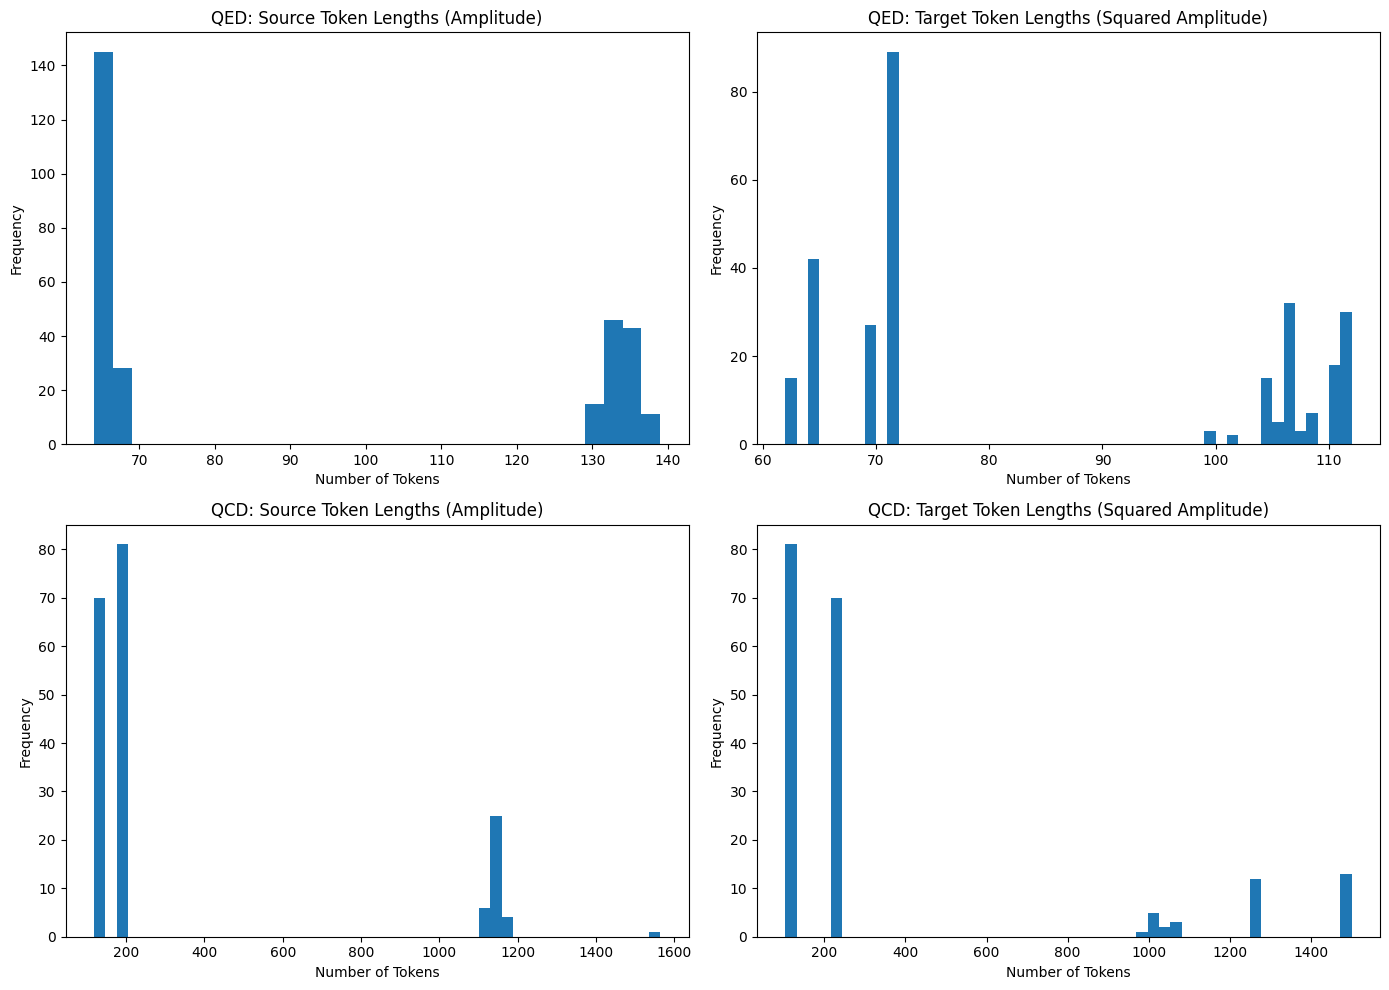

QED Max Source Tokens: 139, Max Target Tokens: 112
QCD Max Source Tokens: 1564, Max Target Tokens: 1500


In [22]:
qed_src_lengths = qed_train['Amplitude_norm'].apply(lambda x: len(tokenizer.src_tokenize(x)))
qed_tgt_lengths = qed_train['Squared_Amplitude_norm'].apply(lambda x: len(tokenizer.tgt_tokenize(x)))

qcd_src_lengths = qcd_train['Amplitude_norm'].apply(lambda x: len(tokenizer.src_tokenize(x)))
qcd_tgt_lengths = qcd_train['Squared_Amplitude_norm'].apply(lambda x: len(tokenizer.tgt_tokenize(x)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# QED Source
axes[0, 0].hist(qed_src_lengths, bins=30)
axes[0, 0].set_title("QED: Source Token Lengths (Amplitude)")

# QED Target
axes[0, 1].hist(qed_tgt_lengths, bins=50)
axes[0, 1].set_title("QED: Target Token Lengths (Squared Amplitude)")

# QCD Source
axes[1, 0].hist(qcd_src_lengths, bins=50)
axes[1, 0].set_title("QCD: Source Token Lengths (Amplitude)")

# QCD Target
axes[1, 1].hist(qcd_tgt_lengths, bins=50)
axes[1, 1].set_title("QCD: Target Token Lengths (Squared Amplitude)")

for ax in axes.flat:
    ax.set_xlabel("Number of Tokens")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"QED Max Source Tokens: {qed_src_lengths.max()}, Max Target Tokens: {qed_tgt_lengths.max()}")
print(f"QCD Max Source Tokens: {qcd_src_lengths.max()}, Max Target Tokens: {qcd_tgt_lengths.max()}")

In [23]:
print("Normalizing Validation sets...")
qed_val_norm = tokenizer.normalize_dataframe_pairs(qed_val)
qcd_val_norm = tokenizer.normalize_dataframe_pairs(qcd_val)

Normalizing Validation sets...


Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/23 [00:00<?, ?it/s]

In [24]:
def count_unks(df, text_col, vocab, tokenize_fn):
    "Counts unknown tokens after tokenization."
    return sum(vocab.encode(tokenize_fn(txt)).count(vocab.unk_idx) for txt in df[text_col])

qed_val_src_unks = count_unks(qed_val_norm, 'Amplitude_norm', qed_src_vocab, tokenizer.src_tokenize)
qed_val_tgt_unks = count_unks(qed_val_norm, 'Squared_Amplitude_norm', qed_tgt_vocab, tokenizer.tgt_tokenize)

qcd_val_src_unks = count_unks(qcd_val_norm, 'Amplitude_norm', qcd_src_vocab, tokenizer.src_tokenize)
qcd_val_tgt_unks = count_unks(qcd_val_norm, 'Squared_Amplitude_norm', qcd_tgt_vocab, tokenizer.tgt_tokenize)

In [25]:
print(f"QED Val <UNK>s [Source: {qed_val_src_unks}, Target: {qed_val_tgt_unks}]")
print(f"QCD Val <UNK>s [Source: {qcd_val_src_unks}, Target: {qcd_val_tgt_unks}]")

QED Val <UNK>s [Source: 0, Target: 0]
QCD Val <UNK>s [Source: 0, Target: 0]
